# Cellpose low-convexity cell segmentation pipeline

- loading images and optional ground-truth masks
- preprocessing
- Cellpose baseline + parameter sweep
- mask-level feature extraction
- instance matching to ground truth
- Dice / IoU evaluation ？
- optional random forest mask-quality modeling (not yet)
- lightweight post-processing and before/after comparison (not yet)

You can run it on a single image first, then switch to a folder of images.

## 1. Imports

In [1]:

import os
import json
import math
import itertools
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tifffile as tiff

from cellpose import models
from cellpose.io import imread

from skimage import exposure, filters, morphology, measure, segmentation, util
from skimage.measure import regionprops, label
from scipy import ndimage as ndi


try:
    import napari
    HAS_NAPARI = True
except Exception:
    HAS_NAPARI = False

plt.rcParams["figure.figsize"] = (8, 8)
from skimage.transform import resize

## 2. Configuration

Edit this block before running.  
You can point `INPUT_PATH` to either a single image file or a folder.

If using a folder, make sure image and GT filenames share the same stem.

In [2]:
"""INPUT_PATH = "/Users/wendywang/Downloads/MP6843_img_full/F01_120w1.TIF"  

imgs = imread(INPUT_PATH)

viewer = napari.Viewer()

viewer.add_image(imgs)
napari.run()"""

'INPUT_PATH = "/Users/wendywang/Downloads/MP6843_img_full/F01_120w1.TIF"  \n\nimgs = imread(INPUT_PATH)\n\nviewer = napari.Viewer()\n\nviewer.add_image(imgs)\nnapari.run()'

In [3]:
BASE = "/Users/sorro/workspace/02604/project/project_cellpose-main"

# After running bbbc020_prepare_data.py, point to the prepared folders:
INPUT_PATH = BASE + "/BBBC020_prepared/images"        # folder of grayscale TIFs
GT_PATH    = BASE + "/BBBC020_prepared/ground_truth"  # folder of instance-mask TIFs
SAVE_ROOT  = BASE + "/results_bbbc020"


# Auto-detect best device: CUDA > MPS (Apple Silicon) > CPU.
# Cellpose v4 (CPSAM) is a ViT-based model; on pure CPU a single image can
# take minutes — the main reason the original notebook appears to hang.
import torch as _torch
if _torch.cuda.is_available():
    USE_GPU = True
    _DEVICE_NAME = "cuda"
elif getattr(_torch.backends, "mps", None) is not None and _torch.backends.mps.is_available():
    USE_GPU = True
    _DEVICE_NAME = "mps"
else:
    USE_GPU = False
    _DEVICE_NAME = "cpu"
print(f"Cellpose device: {_DEVICE_NAME}  (USE_GPU={USE_GPU})")

# model_type is ignored in cellpose >=4.0.1 (CPSAM is the only built-in model),
# but we keep it for logging / metadata.
MODEL_TYPE = "cpsam"

# Preprocessing
DO_NORMALIZE = True
DO_BACKGROUND_SUBTRACT = False
BACKGROUND_SIGMA = 30
DO_DENOISE = False
DENOISE_SIGMA = 1.0

# Baseline Cellpose parameters
BASELINE_CELL_DIAMETER = 40   # macrophages are larger; adjust after seeing baseline result
BASELINE_CELLPROB_THRESHOLD = 0.0
BASELINE_FLOW_THRESHOLD = 0.4

# Parameter sweep — original grid was 4×5×4=80 combos (too slow on CPU/slow
# on MPS). Trimmed grid below = 3×3×2 = 18 combos/image. Feel free to widen
# once you confirm the baseline runs in seconds on your device.
RUN_SWEEP = True
SWEEP_DIAMETERS = [40, 55, 70]
SWEEP_CELLPROB_THRESHOLDS = [-2.0, 0.0, 2.0]
SWEEP_FLOW_THRESHOLDS = [0.3, 0.5]

# In the sweep, skip the heavy per-combo artifacts (preprocessed TIF and
# matplotlib overlay PNGs). Instance masks + metrics are always saved.
SAVE_HEAVY_OUTPUTS_IN_SWEEP = False

# Optional: cap images during the sweep for quick iteration.
SWEEP_MAX_IMAGES = None

# Post-processing
POSTPROCESS_REMOVE_SMALL_OBJECTS = True
MIN_OBJECT_SIZE = 50   # macrophages are larger than neurons
POSTPROCESS_FILL_HOLES = True
MAX_HOLE_SIZE = 50


# Visualization
SHOW_NAPARI = False
SHOW_MATPLOTLIB = True

# For grayscale images, keep CHANNEL_AXIS = None.
# For RGB/multi-channel images, set CHANNEL_AXIS accordingly and adjust preprocess_image if needed.
CHANNEL_AXIS = None
QUALITY_LABEL_DICE_THRESHOLD = 0.5

Cellpose device: mps  (USE_GPU=True)


## 3. Utility functions

In [4]:

VALID_EXTS = {".tif", ".tiff", ".png", ".jpg", ".jpeg", ".bmp"}

#create dir if not exist
def ensure_dir(path):
    Path(path).mkdir(parents=True, exist_ok=True)

#check is the file an image?
def is_image_file(path):
    return Path(path).suffix.lower() in VALID_EXTS

#build image list
def list_images(path_like):
    p = Path(path_like)
    if p.is_file():
        if not is_image_file(p):
            raise ValueError(f"Unsupported image file: {p}")
        return [str(p)]
    elif p.is_dir():
        files = sorted([str(x) for x in p.iterdir() if x.is_file() and is_image_file(x)])
        if not files:
            raise ValueError(f"No image files found in folder: {p}")
        return files
    else:
        raise FileNotFoundError(f"Path not found: {p}")

# returns the filename without extension use for future naming
def stem(path):
    return Path(path).stem

#import gt image mask
def maybe_find_gt(img_path, gt_path):
    if not gt_path:
        return None

    gt_path = str(gt_path).strip()
    p = Path(gt_path)

    if p.is_file():
        return str(p)

    if p.is_dir():
        s = stem(img_path)
        matches = [x for x in p.iterdir() if x.is_file() and x.stem == s and is_image_file(x)]
        if matches:
            return str(matches[0])

    return None

#convert img to float, so we have consistent image for later process
def to_float01(img):
    img = np.asarray(img)

    if img.dtype.kind in "ui":
        maxv = np.iinfo(img.dtype).max
        img = img.astype(np.float32)
        if maxv > 0:
            img = img / maxv
    else:
        img = img.astype(np.float32)

    return img

#rescale intensity
def normalize_percentile(img, p_low=1, p_high=99):
    lo, hi = np.percentile(img, [p_low, p_high])
    out = np.clip((img - lo) / (hi - lo + 1e-8), 0, 1)
    return out.astype(np.float32)

#some image may have uneven illumination or haze-like background so we smooth and substract it
def subtract_background(img, sigma=30):
    bg = filters.gaussian(img, sigma=sigma, preserve_range=True)
    out = img - bg
    out = out - out.min()
    if out.max() > 0:
        out = out / out.max()
    return out.astype(np.float32)


# instead of manually calling several preprocessing steps every time
# this standardizes the full image-prep stage
def preprocess_image(img):
    img = np.asarray(img)
    if img.ndim == 3 and CHANNEL_AXIS is None:
        # if RGB-like, convert to grayscale by mean
        if img.shape[-1] in (3, 4):
            img = img[..., :3].mean(axis=-1)
    img = to_float01(img)

    if DO_NORMALIZE:
        img = normalize_percentile(img)

    if DO_BACKGROUND_SUBTRACT:
        img = subtract_background(img, sigma=BACKGROUND_SIGMA)

    if DO_DENOISE:
        img = filters.gaussian(img, sigma=DENOISE_SIGMA, preserve_range=True)

    return img.astype(np.float32)

# no need to say more
def save_json(obj, path):
    with open(path, "w") as f:
        json.dump(obj, f, indent=2)

#visualization by drawing mask boundaries
def overlay_boundaries(image, mask):
    image = np.asarray(image)
    mask = np.asarray(mask)

    if image.shape[:2] != mask.shape[:2]:
        raise ValueError(
            f"Image shape {image.shape[:2]} and mask shape {mask.shape[:2]} do not match"
        )

    img = image.astype(np.float32)

    if img.ndim == 2:
        pass
    elif img.ndim == 3:
        if img.shape[-1] == 1:
            img = img[..., 0]
        elif img.shape[0] == 1:
            img = img[0]
        elif img.shape[-1] in (3, 4):
            img = img[..., :3].mean(axis=-1)
        else:
            raise ValueError(f"Unsupported image shape for overlay: {img.shape}")
    else:
        raise ValueError(f"Unsupported image ndim for overlay: {img.ndim}")

    if img.max() > img.min():
        img = (img - img.min()) / (img.max() - img.min())
    else:
        img = np.zeros_like(img, dtype=np.float32)

    over = np.stack([img, img, img], axis=-1)

    boundaries = segmentation.find_boundaries(mask, mode="outer")

    over[..., 0][boundaries] = 1.0
    over[..., 1][boundaries] = 0.0
    over[..., 2][boundaries] = 0.0

    return np.clip(over, 0, 1)

# no need to say more as well?
def save_overlay_png(image, mask, path, title=None):
    over = overlay_boundaries(image, mask)
    plt.figure(figsize=(7, 7))
    plt.imshow(over, cmap="gray")
    if title:
        plt.title(title)
    plt.axis("off")
    plt.tight_layout()
    plt.savefig(path, dpi=200, bbox_inches="tight")
    plt.close()

# resize mask if it's diff from img shape
# might influence quantification result need to modify? maybe
def resize_label_mask(mask, target_shape):
    return resize(
        mask,
        target_shape,
        order=0,
        preserve_range=True,
        anti_aliasing=False
    ).astype(mask.dtype)

# clear mask label and dimension and shape
def sanitize_label_mask(mask):
    mask = np.asarray(mask)

    # Case 1: already 2D
    if mask.ndim == 2:
        return mask

    # Case 2: singleton dimension like (1, H, W) or (H, W, 1)
    if mask.ndim == 3:
        if mask.shape[0] == 1:
            return mask[0]
        if mask.shape[-1] == 1:
            return mask[..., 0]

        # Case 3: RGB-like mask (H, W, 3) or (H, W, 4)
        if mask.shape[-1] in (3, 4):
            # If channels are identical, keep one channel
            if np.all(mask[..., 0] == mask[..., 1]) and np.all(mask[..., 0] == mask[..., 2]):
                return mask[..., 0]

            # Otherwise convert nonzero pixels into foreground labels
            # This is only safe if GT is binary-style coloring
            return (np.any(mask[..., :3] > 0, axis=-1)).astype(np.int32)

    raise ValueError(f"Unsupported GT mask shape: {mask.shape}")

## 4. Segmentation and post-processing functions

In [5]:
# ---------------------------------------------------------------------------
# Model loading
# ---------------------------------------------------------------------------
# cellpose >=4.0.1 always loads the SAM-based CPSAM weights, which is slow.
# Re-creating CellposeModel on every inference was the #1 cause of the
# original notebook being so slow. Cache one model per GPU flag so the sweep
# reuses it.
_MODEL_CACHE = {}


def get_cellpose_model(use_gpu=USE_GPU, **_ignored):
    """Return a cached CellposeModel. `model_type` is ignored in cellpose v4+."""
    key = bool(use_gpu)
    model = _MODEL_CACHE.get(key)
    if model is None:
        model = models.CellposeModel(gpu=use_gpu)
        _MODEL_CACHE[key] = model
    return model


def run_cellpose_single(
    img,
    diameter,
    cellprob_threshold,
    flow_threshold,
    model_type=MODEL_TYPE,
    use_gpu=USE_GPU,
    model=None,
):
    """Run one Cellpose inference. Pass `model=` to reuse a preloaded model."""
    if model is None:
        model = get_cellpose_model(use_gpu=use_gpu)
    masks, flows, styles = model.eval(
        img,
        diameter=diameter,
        cellprob_threshold=cellprob_threshold,
        flow_threshold=flow_threshold,
    )
    return masks, flows, styles


# ---------------------------------------------------------------------------
# Post-processing
# ---------------------------------------------------------------------------
# Vectorized clean-up via bounding-box crops. Avoids allocating a full H×W
# boolean per label and avoids repeated whole-image measure.label calls.
def postprocess_instance_masks(mask):
    mask = np.asarray(mask)
    if mask.size == 0 or mask.max() == 0:
        return np.zeros_like(mask, dtype=np.int32)

    labels = np.unique(mask)
    labels = labels[labels != 0]
    if labels.size == 0:
        return np.zeros_like(mask, dtype=np.int32)

    objects = ndi.find_objects(mask.astype(np.int64))
    cleaned = np.zeros_like(mask, dtype=np.int32)
    next_id = 1

    for lab in labels:
        sl = objects[int(lab) - 1] if int(lab) - 1 < len(objects) else None
        if sl is None:
            continue
        sub = mask[sl] == lab
        if not sub.any():
            continue

        if POSTPROCESS_FILL_HOLES:
            sub = morphology.remove_small_holes(sub, area_threshold=MAX_HOLE_SIZE)
        if POSTPROCESS_REMOVE_SMALL_OBJECTS:
            sub = morphology.remove_small_objects(sub, min_size=MIN_OBJECT_SIZE)
        if not sub.any():
            continue

        cc, n_cc = ndi.label(sub)
        for sub_lab in range(1, n_cc + 1):
            region = cc == sub_lab
            if not region.any():
                continue
            cleaned[sl][region] = next_id
            next_id += 1

    return cleaned

## 5. Metrics and instance matching

In [6]:
from skimage.segmentation import relabel_sequential as _sk_relabel_sequential

# computes Dice coefficient between two binary masks
def binary_dice(a, b):
    a = a.astype(bool)
    b = b.astype(bool)
    inter = np.logical_and(a, b).sum()
    denom = a.sum() + b.sum()
    return (2 * inter / denom) if denom > 0 else 1.0

# computes Intersection over Union
def binary_iou(a, b):
    a = a.astype(bool)
    b = b.astype(bool)
    inter = np.logical_and(a, b).sum()
    union = np.logical_or(a, b).sum()
    return (inter / union) if union > 0 else 1.0

# returns all object labels except background
def mask_to_instances(mask):
    labels = np.unique(mask)
    labels = labels[labels != 0]
    return labels

# Vectorized consecutive relabeling via skimage (replaces the per-label
# Python loop with C-level code).
def relabel_sequential(mask):
    relabeled, _, _ = _sk_relabel_sequential(np.asarray(mask).astype(np.int32))
    return relabeled.astype(np.int32)


def _instance_overlap_matrix(pred_mask, gt_mask):
    """Return (overlap, pred_areas, gt_areas) via a single bincount pass.

    overlap[i, j] = #pixels where pred_label==i AND gt_label==j. Row/col 0
    are background. This replaces the O(P*G) nested-loop matching with an
    O(H*W) histogram.
    """
    pred = np.asarray(pred_mask).astype(np.int64, copy=False)
    gt = np.asarray(gt_mask).astype(np.int64, copy=False)
    n_pred = int(pred.max()) + 1
    n_gt = int(gt.max()) + 1

    combined = pred.ravel() * n_gt + gt.ravel()
    counts = np.bincount(combined, minlength=n_pred * n_gt)
    overlap = counts.reshape(n_pred, n_gt)

    pred_areas = overlap.sum(axis=1)
    gt_areas = overlap.sum(axis=0)
    return overlap, pred_areas, gt_areas


# for each predicted object, finds the GT object with the highest overlap
def object_match_table(pred_mask, gt_mask):
    pred_mask = relabel_sequential(pred_mask)
    gt_mask = relabel_sequential(gt_mask)

    pred_labels = mask_to_instances(pred_mask)
    gt_labels = mask_to_instances(gt_mask)

    if pred_labels.size == 0:
        return pd.DataFrame(
            columns=["pred_label", "matched_gt_label", "best_iou", "best_dice"]
        )

    overlap, pred_areas, gt_areas = _instance_overlap_matrix(pred_mask, gt_mask)
    overlap_fg = overlap[1:, 1:]
    pred_area_fg = pred_areas[1:]
    gt_area_fg = gt_areas[1:]

    if overlap_fg.size == 0 or gt_labels.size == 0:
        return pd.DataFrame([
            {"pred_label": int(pl), "matched_gt_label": 0, "best_iou": 0.0, "best_dice": 0.0}
            for pl in pred_labels
        ])

    union = (
        pred_area_fg[:, None]
        + gt_area_fg[None, :]
        - overlap_fg
    )
    with np.errstate(divide="ignore", invalid="ignore"):
        iou = np.where(union > 0, overlap_fg / union, 0.0)
        denom = pred_area_fg[:, None] + gt_area_fg[None, :]
        dice = np.where(denom > 0, 2.0 * overlap_fg / denom, 0.0)

    best_j = iou.argmax(axis=1)
    best_iou = iou[np.arange(iou.shape[0]), best_j]
    best_dice = dice[np.arange(dice.shape[0]), best_j]
    matched_gt = np.where(best_iou > 0, best_j + 1, 0)

    return pd.DataFrame({
        "pred_label": pred_labels.astype(int),
        "matched_gt_label": matched_gt.astype(int),
        "best_iou": best_iou.astype(float),
        "best_dice": best_dice.astype(float),
    })


# whole image matrics
def image_level_metrics(pred_mask, gt_mask):
    pred_bin = pred_mask > 0
    gt_bin = gt_mask > 0
    return {
        "image_dice_binary": float(binary_dice(pred_bin, gt_bin)),
        "image_iou_binary": float(binary_iou(pred_bin, gt_bin)),
        "n_pred_instances": int(len(mask_to_instances(pred_mask))),
        "n_gt_instances": int(len(mask_to_instances(gt_mask))),
    }

## 6. Feature extraction

In [7]:
from skimage.measure import regionprops_table

# Shape & intensity features for every instance.
#
# Speedups vs. the original implementation:
#   * filters.sobel(image) is computed ONCE, not once per object.
#   * Basic geometry comes from regionprops_table (C-level, vectorized) in a
#     single pass instead of constructing a RegionProperties per cell.
#   * Skeletonization is applied only on each bounding-box crop.
#   * Boundary edge strength is computed per-crop as well.
#
# Set `include_skeleton=False` to skip skeletonize entirely (useful in the
# parameter sweep where this feature isn't essential).
def compute_object_features(mask, image, include_skeleton=True):
    image = np.asarray(image)
    mask = relabel_sequential(mask)

    if mask.max() == 0:
        cols = [
            "pred_label", "area", "perimeter", "convex_area", "convexity",
            "solidity", "eccentricity", "major_axis_length", "minor_axis_length",
            "circularity", "bbox_area", "extent", "skeleton_length",
            "mean_intensity", "boundary_edge_strength",
        ]
        return pd.DataFrame(columns=cols)

    props = regionprops_table(
        mask,
        intensity_image=image,
        properties=(
            "label", "area", "perimeter", "convex_area", "solidity",
            "eccentricity", "major_axis_length", "minor_axis_length",
            "bbox", "mean_intensity",
        ),
    )
    df = pd.DataFrame(props).rename(columns={"label": "pred_label"})

    perimeter = df["perimeter"].to_numpy(dtype=float)
    area = df["area"].to_numpy(dtype=float)
    convex_area = df["convex_area"].to_numpy(dtype=float)

    with np.errstate(divide="ignore", invalid="ignore"):
        df["circularity"] = np.where(
            perimeter > 0, 4 * math.pi * area / (perimeter ** 2 + 1e-8), np.nan
        )
        df["convexity"] = np.where(
            convex_area > 0, area / convex_area, np.nan
        )
        bbox_area = (df["bbox-2"] - df["bbox-0"]) * (df["bbox-3"] - df["bbox-1"])
        df["bbox_area"] = bbox_area.astype(float)
        df["extent"] = np.where(bbox_area > 0, area / bbox_area, np.nan)

    sobel_full = filters.sobel(image.astype(np.float32))
    objects = ndi.find_objects(mask)

    edge_strength = np.zeros(len(df), dtype=float)
    skeleton_length = np.zeros(len(df), dtype=float)

    for i, lab in enumerate(df["pred_label"].to_numpy()):
        sl = objects[int(lab) - 1] if int(lab) - 1 < len(objects) else None
        if sl is None:
            continue
        sub = mask[sl] == lab
        if not sub.any():
            continue
        boundary = segmentation.find_boundaries(sub, mode="outer")
        if boundary.any():
            edge_strength[i] = float(sobel_full[sl][boundary].mean())
        if include_skeleton:
            skel = morphology.skeletonize(sub)
            skeleton_length[i] = float(skel.sum())

    df["boundary_edge_strength"] = edge_strength
    df["skeleton_length"] = skeleton_length

    df = df[[
        "pred_label", "area", "perimeter", "convex_area", "convexity",
        "solidity", "eccentricity", "major_axis_length", "minor_axis_length",
        "circularity", "bbox_area", "extent", "skeleton_length",
        "mean_intensity", "boundary_edge_strength",
    ]]
    return df

# add Cellpose-derived confidence-like values to each object like mean cell prob 
#but currently not working still fixing
def attach_cellpose_confidence_features(df, mask, flows):

    out = df.copy()
    prob_map = None

    if isinstance(flows, (list, tuple)) and len(flows) > 2:
        arr = np.asarray(flows[2])
        if arr.ndim >= 2:
            prob_map = arr

    if prob_map is None:
        out["mean_cellprob"] = np.nan
        out["max_cellprob"] = np.nan
        return out

    if prob_map.ndim > 2:
        prob_map = np.squeeze(prob_map)
        if prob_map.ndim > 2:
            prob_map = prob_map[0]

    mean_probs = []
    max_probs = []
    for lab in out["pred_label"]:
        obj = mask == int(lab)
        vals = prob_map[obj]
        mean_probs.append(float(np.mean(vals)) if vals.size > 0 else np.nan)
        max_probs.append(float(np.max(vals)) if vals.size > 0 else np.nan)

    out["mean_cellprob"] = mean_probs
    out["max_cellprob"] = max_probs
    return out

## 7. Single-run pipeline

In [8]:

def run_pipeline_on_image(
    img_path,
    gt_path=None,
    save_root=SAVE_ROOT,
    diameter=BASELINE_CELL_DIAMETER,
    cellprob_threshold=BASELINE_CELLPROB_THRESHOLD,
    flow_threshold=BASELINE_FLOW_THRESHOLD,
    model_type=MODEL_TYPE,
    use_gpu=USE_GPU,
    apply_postprocess=True,
    model=None,
    save_heavy=True,
    preproc_img=None,
    gt_mask_cached=None,
    include_skeleton=True,
):
    """Run the full per-image pipeline.

    New optional performance knobs:
      * `model` – preloaded CellposeModel; avoids reloading weights per call.
      * `save_heavy` – if False, skip preprocessed TIF + overlay PNGs.
      * `preproc_img` / `gt_mask_cached` – caller-provided cached arrays so a
        parameter sweep can reuse the expensive I/O and preprocessing.
      * `include_skeleton` – disable per-cell skeletonize.
    """
    img_name = stem(img_path)
    run_name = f"d{diameter}_cp{cellprob_threshold}_ft{flow_threshold}"
    out_dir = os.path.join(save_root, img_name, run_name)
    ensure_dir(out_dir)

    if preproc_img is None:
        raw_img = imread(img_path)
        proc_img = preprocess_image(raw_img)
    else:
        proc_img = preproc_img

    pred_mask, flows, styles = run_cellpose_single(
        proc_img,
        diameter=diameter,
        cellprob_threshold=cellprob_threshold,
        flow_threshold=flow_threshold,
        model_type=model_type,
        use_gpu=use_gpu,
        model=model,
    )

    pred_mask = relabel_sequential(pred_mask)
    pred_mask_post = postprocess_instance_masks(pred_mask) if apply_postprocess else pred_mask.copy()

    # Masks are small, always save them.
    tiff.imwrite(os.path.join(out_dir, "pred_mask_raw.tif"), pred_mask.astype(np.int32))
    tiff.imwrite(os.path.join(out_dir, "pred_mask_post.tif"), pred_mask_post.astype(np.int32))

    # Heavy artifacts only in baseline / explicit-save mode.
    if save_heavy:
        tiff.imwrite(
            os.path.join(out_dir, "image_preprocessed.tif"),
            proc_img.astype(np.float32),
        )
        save_overlay_png(
            proc_img, pred_mask, os.path.join(out_dir, "overlay_raw.png"),
            title=f"{img_name} raw",
        )
        save_overlay_png(
            proc_img, pred_mask_post, os.path.join(out_dir, "overlay_post.png"),
            title=f"{img_name} post",
        )

    params = {
        "img_path": img_path,
        "gt_path": gt_path,
        "diameter": diameter,
        "cellprob_threshold": cellprob_threshold,
        "flow_threshold": flow_threshold,
        "model_type": model_type,
        "use_gpu": use_gpu,
        "apply_postprocess": apply_postprocess,
    }
    save_json(params, os.path.join(out_dir, "params.json"))

    feat_raw = compute_object_features(
        pred_mask, proc_img, include_skeleton=include_skeleton
    )
    feat_raw = attach_cellpose_confidence_features(feat_raw, pred_mask, flows)
    feat_raw["image_name"] = img_name
    feat_raw["run_name"] = run_name
    feat_raw["postprocess"] = False

    feat_post = compute_object_features(
        pred_mask_post, proc_img, include_skeleton=include_skeleton
    )
    feat_post["mean_cellprob"] = np.nan
    feat_post["max_cellprob"] = np.nan
    feat_post["image_name"] = img_name
    feat_post["run_name"] = run_name
    feat_post["postprocess"] = True

    image_metrics_raw = {}
    image_metrics_post = {}

    if gt_path or gt_mask_cached is not None:
        if gt_mask_cached is not None:
            gt_mask = gt_mask_cached
        else:
            gt_mask = imread(gt_path)
            gt_mask = sanitize_label_mask(gt_mask)
            if gt_mask.shape[:2] != proc_img.shape[:2]:
                print(f"Resizing GT from {gt_mask.shape[:2]} to {proc_img.shape[:2]}")
                gt_mask = resize_label_mask(gt_mask, proc_img.shape[:2])
            gt_mask = relabel_sequential(gt_mask)

        if save_heavy:
            tiff.imwrite(os.path.join(out_dir, "gt_mask.tif"), gt_mask.astype(np.int32))
            save_overlay_png(
                proc_img, gt_mask, os.path.join(out_dir, "overlay_gt.png"),
                title=f"{img_name} GT",
            )

        raw_match_df = object_match_table(pred_mask, gt_mask)
        post_match_df = object_match_table(pred_mask_post, gt_mask)

        if not feat_raw.empty and not raw_match_df.empty:
            feat_raw = feat_raw.merge(raw_match_df, on="pred_label", how="left")
        else:
            feat_raw["best_dice"] = np.nan
            feat_raw["best_iou"] = np.nan
            feat_raw["matched_gt_label"] = np.nan

        if not feat_post.empty and not post_match_df.empty:
            feat_post = feat_post.merge(post_match_df, on="pred_label", how="left")
        else:
            feat_post["best_dice"] = np.nan
            feat_post["best_iou"] = np.nan
            feat_post["matched_gt_label"] = np.nan

        feat_raw["quality_good"] = (feat_raw["best_dice"] >= QUALITY_LABEL_DICE_THRESHOLD).astype(int)
        feat_post["quality_good"] = (feat_post["best_dice"] >= QUALITY_LABEL_DICE_THRESHOLD).astype(int)

        image_metrics_raw = image_level_metrics(pred_mask, gt_mask)
        image_metrics_post = image_level_metrics(pred_mask_post, gt_mask)

        save_json(image_metrics_raw, os.path.join(out_dir, "image_metrics_raw.json"))
        save_json(image_metrics_post, os.path.join(out_dir, "image_metrics_post.json"))

    feat_raw.to_csv(os.path.join(out_dir, "features_raw.csv"), index=False)
    feat_post.to_csv(os.path.join(out_dir, "features_post.csv"), index=False)

    return {
        "img_path": img_path,
        "gt_path": gt_path,
        "proc_img": proc_img,
        "pred_mask_raw": pred_mask,
        "pred_mask_post": pred_mask_post,
        "features_raw": feat_raw,
        "features_post": feat_post,
        "image_metrics_raw": image_metrics_raw,
        "image_metrics_post": image_metrics_post,
        "out_dir": out_dir,
    }

## 8. Run a single baseline (tester)

In [9]:
import time

ensure_dir(SAVE_ROOT)

image_files = list_images(INPUT_PATH)
single_img = image_files[0]
single_gt = maybe_find_gt(single_img, GT_PATH)

# Load CellposeModel ONCE and cache it — this is the single biggest cost
# in cellpose v4 (CPSAM weights + first forward pass). Subsequent cells
# reuse this handle via _MODEL_CACHE.
t0 = time.time()
print(f"Loading CellposeModel (gpu={USE_GPU})...")
cellpose_model = get_cellpose_model(use_gpu=USE_GPU)
print(f"  model ready in {time.time() - t0:.1f}s")

t0 = time.time()
single_result = run_pipeline_on_image(
    img_path=single_img,
    gt_path=single_gt,
    save_root=SAVE_ROOT,
    diameter=BASELINE_CELL_DIAMETER,
    cellprob_threshold=BASELINE_CELLPROB_THRESHOLD,
    flow_threshold=BASELINE_FLOW_THRESHOLD,
    model_type=MODEL_TYPE,
    use_gpu=USE_GPU,
    apply_postprocess=True,
    model=cellpose_model,
    save_heavy=True,
)
print(f"Baseline run finished in {time.time() - t0:.1f}s")

print("Saved to:", single_result["out_dir"])
if single_result["image_metrics_raw"]:
    print("Raw image metrics:", single_result["image_metrics_raw"])
    print("Post image metrics:", single_result["image_metrics_post"])

single_result["features_post"].head()

Loading CellposeModel (gpu=True)...
  model ready in 2.4s
Baseline run finished in 19.6s
Saved to: /Users/sorro/workspace/02604/project/project_cellpose-main/results_bbbc020/jw-15min 1_c1/d40_cp0.0_ft0.4
Raw image metrics: {'image_dice_binary': 0.7567474626555781, 'image_iou_binary': 0.6086836261536895, 'n_pred_instances': 49, 'n_gt_instances': 29}
Post image metrics: {'image_dice_binary': 0.7564565384992668, 'image_iou_binary': 0.6083072782887377, 'n_pred_instances': 49, 'n_gt_instances': 29}


,pred_label,area,perimeter,convex_area,convexity,solidity,eccentricity,major_axis_length,minor_axis_length,circularity,...,boundary_edge_strength,mean_cellprob,max_cellprob,image_name,run_name,postprocess,matched_gt_label,best_iou,best_dice,quality_good
0,1,2964.0,317.178716,3493.0,0.848554,0.848554,0.979261,145.316968,29.441576,0.370237,...,0.018868,NaN,NaN,jw-15min 1_c1,d40_cp0.0_ft0.4,True,0,0.000000,0.000000,0
1,2,8110.0,558.766594,10451.0,0.776002,0.776002,0.979784,257.392745,51.493540,0.326415,...,0.050648,NaN,NaN,jw-15min 1_c1,d40_cp0.0_ft0.4,True,8,0.853096,0.920725,1
2,3,10075.0,495.119841,10715.0,0.940271,0.940271,0.915026,189.765811,76.550628,0.516457,...,0.063380,NaN,NaN,jw-15min 1_c1,d40_cp0.0_ft0.4,True,8,0.015750,0.031011,0
3,4,12012.0,560.658946,16079.0,0.747061,0.747061,0.776331,173.087496,109.101391,0.480206,...,0.029623,NaN,NaN,jw-15min 1_c1,d40_cp0.0_ft0.4,True,0,0.000000,0.000000,0
4,5,19186.0,717.629509,22636.0,0.847588,0.847588,0.938916,279.297043,96.118890,0.468159,...,0.054326,NaN,NaN,jw-15min 1_c1,d40_cp0.0_ft0.4,True,0,0.000000,0.000000,0


## 9. Visualize the baseline result

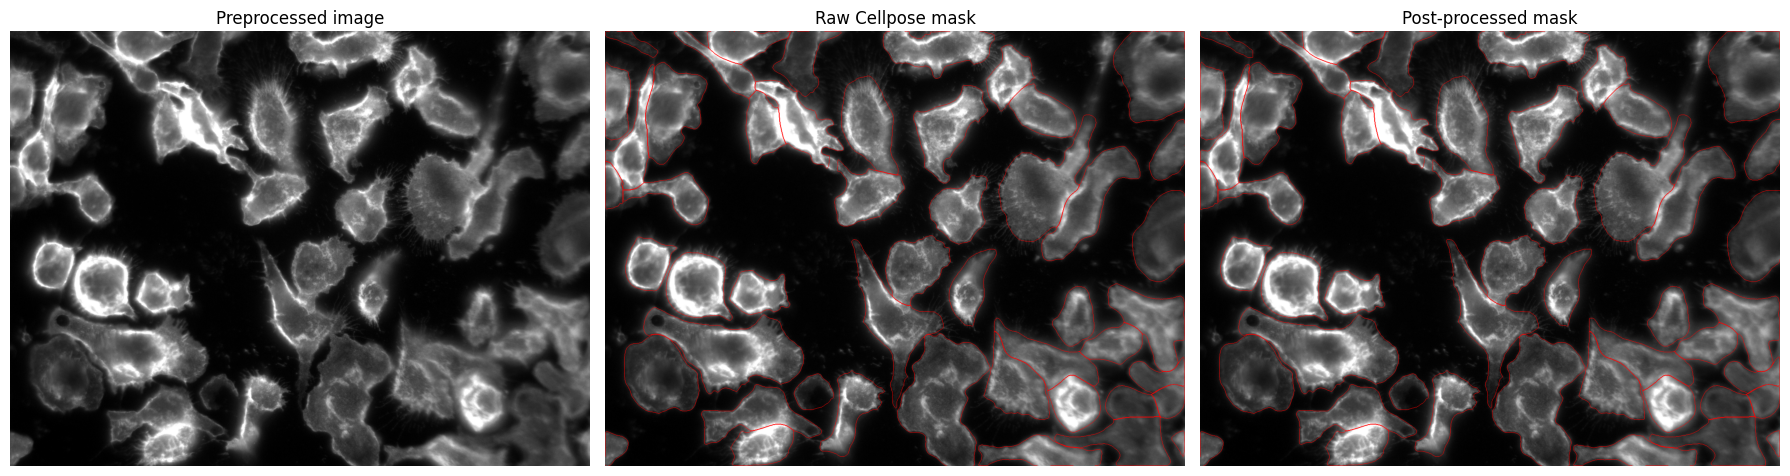

In [10]:

if SHOW_MATPLOTLIB:
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    axes[0].imshow(single_result["proc_img"], cmap="gray")
    axes[0].set_title("Preprocessed image")
    axes[0].axis("off")

    axes[1].imshow(overlay_boundaries(single_result["proc_img"], single_result["pred_mask_raw"]))
    axes[1].set_title("Raw Cellpose mask")
    axes[1].axis("off")

    axes[2].imshow(overlay_boundaries(single_result["proc_img"], single_result["pred_mask_post"]))
    axes[2].set_title("Post-processed mask")
    axes[2].axis("off")

    plt.tight_layout()
    plt.show()

if SHOW_NAPARI and HAS_NAPARI:
    viewer = napari.Viewer()
    viewer.add_image(single_result["proc_img"], name="image")
    viewer.add_labels(single_result["pred_mask_raw"], name="pred_raw")
    viewer.add_labels(single_result["pred_mask_post"], name="pred_post")
    napari.run()

## 10. All Image in Folder and All parameter combination

This runs the full pipeline over all images and all requested parameter combinations.

In [11]:
from tqdm.auto import tqdm

all_results = []
all_feature_tables = []

if RUN_SWEEP:
    combos = list(itertools.product(
        SWEEP_DIAMETERS, SWEEP_CELLPROB_THRESHOLDS, SWEEP_FLOW_THRESHOLDS
    ))

    images_for_sweep = image_files
    if SWEEP_MAX_IMAGES is not None:
        images_for_sweep = images_for_sweep[: int(SWEEP_MAX_IMAGES)]

    total_runs = len(combos) * len(images_for_sweep)
    print(
        f"Sweep: {len(combos)} param combos × {len(images_for_sweep)} image(s)"
        f" = {total_runs} total Cellpose runs"
    )

    # Ensure the model is loaded before we start timing individual runs.
    cellpose_model = get_cellpose_model(use_gpu=USE_GPU)

    pbar = tqdm(total=total_runs, desc="sweep", unit="run")

    for img_path in images_for_sweep:
        gt_path = maybe_find_gt(img_path, GT_PATH)

        # Preprocess each image + GT exactly once, reuse across all combos.
        raw_img = imread(img_path)
        proc_img = preprocess_image(raw_img)

        gt_mask_cached = None
        if gt_path:
            _gt = imread(gt_path)
            _gt = sanitize_label_mask(_gt)
            if _gt.shape[:2] != proc_img.shape[:2]:
                _gt = resize_label_mask(_gt, proc_img.shape[:2])
            gt_mask_cached = relabel_sequential(_gt)

        for diameter, cp, ft in combos:
            res = run_pipeline_on_image(
                img_path=img_path,
                gt_path=gt_path,
                save_root=SAVE_ROOT,
                diameter=diameter,
                cellprob_threshold=cp,
                flow_threshold=ft,
                model_type=MODEL_TYPE,
                use_gpu=USE_GPU,
                apply_postprocess=True,
                model=cellpose_model,
                save_heavy=SAVE_HEAVY_OUTPUTS_IN_SWEEP,
                preproc_img=proc_img,
                gt_mask_cached=gt_mask_cached,
                include_skeleton=False,  # skip per-cell skeletonize during sweep
            )

            row = {
                "image_name": stem(img_path),
                "diameter": diameter,
                "cellprob_threshold": cp,
                "flow_threshold": ft,
                **{f"raw_{k}": v for k, v in res["image_metrics_raw"].items()},
                **{f"post_{k}": v for k, v in res["image_metrics_post"].items()},
                "out_dir": res["out_dir"],
            }
            all_results.append(row)

            all_feature_tables.append(res["features_raw"])
            all_feature_tables.append(res["features_post"])
            pbar.update(1)

    pbar.close()

    summary_df = pd.DataFrame(all_results)
    feature_df = (
        pd.concat(all_feature_tables, ignore_index=True)
        if all_feature_tables
        else pd.DataFrame()
    )

    summary_path = os.path.join(SAVE_ROOT, "sweep_summary.csv")
    features_path = os.path.join(SAVE_ROOT, "all_features.csv")
    summary_df.to_csv(summary_path, index=False)
    feature_df.to_csv(features_path, index=False)

    print("Saved:", summary_path)
    print("Saved:", features_path)
    display(summary_df.head())
else:
    summary_df = pd.DataFrame()
    feature_df = pd.DataFrame()

Sweep: 18 param combos × 20 image(s) = 360 total Cellpose runs


sweep:   0%|          | 0/360 [00:00<?, ?run/s]

Saved: /Users/sorro/workspace/02604/project/project_cellpose-main/results_bbbc020/sweep_summary.csv
Saved: /Users/sorro/workspace/02604/project/project_cellpose-main/results_bbbc020/all_features.csv


,image_name,diameter,cellprob_threshold,flow_threshold,raw_image_dice_binary,raw_image_iou_binary,raw_n_pred_instances,raw_n_gt_instances,post_image_dice_binary,post_image_iou_binary,post_n_pred_instances,post_n_gt_instances,out_dir
0,jw-15min 1_c1,40,-2.0,0.3,0.730102,0.574930,42,29,0.729918,0.574701,42,29,/Users/sorro/workspace/02604/project/project_c...
1,jw-15min 1_c1,40,-2.0,0.5,0.730370,0.575263,49,29,0.730190,0.575039,49,29,/Users/sorro/workspace/02604/project/project_c...
2,jw-15min 1_c1,40,0.0,0.3,0.764144,0.618311,46,29,0.763902,0.617995,46,29,/Users/sorro/workspace/02604/project/project_c...
3,jw-15min 1_c1,40,0.0,0.5,0.756747,0.608684,49,29,0.756457,0.608307,49,29,/Users/sorro/workspace/02604/project/project_c...
4,jw-15min 1_c1,40,2.0,0.3,0.755513,0.607088,45,29,0.755559,0.607147,45,29,/Users/sorro/workspace/02604/project/project_c...


## 11. Inspect the best settings


In [12]:

if not summary_df.empty and "post_image_dice_binary" in summary_df.columns:
    best_summary = summary_df.sort_values(
        by=["post_image_dice_binary", "post_image_iou_binary"],
        ascending=False
    )
    display(best_summary.head(10))
else:
    print("No sweep summary with GT-based image metrics available yet.")

,image_name,diameter,cellprob_threshold,flow_threshold,raw_image_dice_binary,raw_image_iou_binary,raw_n_pred_instances,raw_n_gt_instances,post_image_dice_binary,post_image_iou_binary,post_n_pred_instances,post_n_gt_instances,out_dir
260,jw-24h 5_c1,55,0.0,0.3,0.885855,0.795099,29,20,0.885555,0.794616,29,20,/Users/sorro/workspace/02604/project/project_c...
261,jw-24h 5_c1,55,0.0,0.5,0.885855,0.795099,29,20,0.885555,0.794616,29,20,/Users/sorro/workspace/02604/project/project_c...
266,jw-24h 5_c1,70,0.0,0.3,0.884450,0.792838,30,20,0.883939,0.792017,30,20,/Users/sorro/workspace/02604/project/project_c...
267,jw-24h 5_c1,70,0.0,0.5,0.884450,0.792838,30,20,0.883939,0.792017,30,20,/Users/sorro/workspace/02604/project/project_c...
254,jw-24h 5_c1,40,0.0,0.3,0.884237,0.792495,30,20,0.883762,0.791732,30,20,/Users/sorro/workspace/02604/project/project_c...
255,jw-24h 5_c1,40,0.0,0.5,0.884237,0.792495,30,20,0.883762,0.791732,30,20,/Users/sorro/workspace/02604/project/project_c...
51,jw-15min 3_c1,70,0.0,0.5,0.875391,0.778395,34,27,0.875295,0.778244,34,27,/Users/sorro/workspace/02604/project/project_c...
268,jw-24h 5_c1,70,2.0,0.3,0.870874,0.771282,27,20,0.870690,0.770993,27,20,/Users/sorro/workspace/02604/project/project_c...
269,jw-24h 5_c1,70,2.0,0.5,0.870874,0.771282,27,20,0.870690,0.770993,27,20,/Users/sorro/workspace/02604/project/project_c...
45,jw-15min 3_c1,55,0.0,0.5,0.870473,0.770652,35,27,0.870231,0.770273,35,27,/Users/sorro/workspace/02604/project/project_c...


# 12. Random forest for mask quality

Train a Random Forest to predict segmentation quality (`post_image_dice_binary`) from the three Cellpose parameters.
This surrogate is fast to query and guides the Gaussian Process optimizer in the next section.

**One-time install** (everything else is already in your `cellpose` env):
```
pip install scikit-optimize
```

In [13]:
# Uncomment and run once if scikit-optimize is not yet installed:
# !pip install scikit-optimize

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings("ignore")

try:
    from skopt import gp_minimize
    from skopt.space import Real
    from skopt.utils import use_named_args
    HAS_SKOPT = True
    print("scikit-optimize ready.")
except ImportError:
    HAS_SKOPT = False
    print("scikit-optimize not found. Install with:  pip install scikit-optimize")

scikit-optimize ready.


RF surrogate  CV R²: -3.210 ± 6.978
  ⚠  Low R² — widen SWEEP_* ranges in Section 2 for a better surrogate.

Feature importance:
  cellprob_threshold        0.729  █████████████████████████████
  diameter                  0.239  █████████
  flow_threshold            0.032  █


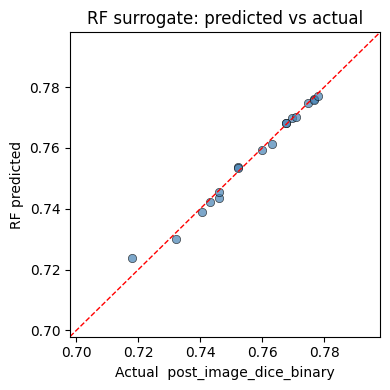


Surrogate ready — proceed to Section 13.


In [14]:
# ── Config ────────────────────────────────────────────────────────────────────
# Which metric to optimise.  Must be a column in summary_df.
#   'post_image_dice_binary'  (recommended)
#   'post_image_iou_binary'
#   'raw_image_dice_binary'
RF_TARGET_METRIC = "post_image_dice_binary"

PARAM_FEATURES = ["diameter", "cellprob_threshold", "flow_threshold"]

# ── Build training set from sweep summary ─────────────────────────────────────
if summary_df.empty:
    print("summary_df is empty — run Section 10 (parameter sweep) first.")
elif RF_TARGET_METRIC not in summary_df.columns:
    print(f"Column '{RF_TARGET_METRIC}' not found. Run sweep with GT masks attached.")
else:
    # Aggregate: mean Dice per parameter combo across all images
    rf_df = (
        summary_df
        .groupby(PARAM_FEATURES)[RF_TARGET_METRIC]
        .mean()
        .reset_index()
        .rename(columns={RF_TARGET_METRIC: "target"})
    )

    X_rf = rf_df[PARAM_FEATURES].values
    y_rf = rf_df["target"].values

    scaler_rf = StandardScaler()
    X_rf_sc   = scaler_rf.fit_transform(X_rf)

    surrogate = RandomForestRegressor(
        n_estimators=300,
        min_samples_leaf=1,
        random_state=42,
        n_jobs=-1,
    )
    surrogate.fit(X_rf_sc, y_rf)

    # ── Cross-validation quality check ───────────────────────────────────────
    if len(rf_df) >= 5:
        cv_r2 = cross_val_score(surrogate, X_rf_sc, y_rf, cv=min(5, len(rf_df)), scoring="r2")
        print(f"RF surrogate  CV R²: {cv_r2.mean():.3f} ± {cv_r2.std():.3f}")
        if cv_r2.mean() < 0.5:
            print("  ⚠  Low R² — widen SWEEP_* ranges in Section 2 for a better surrogate.")
    else:
        print(f"RF fitted on {len(rf_df)} combos (run a wider sweep for CV reliability).")

    # ── Feature importance ───────────────────────────────────────────────────
    importances = dict(zip(PARAM_FEATURES, surrogate.feature_importances_))
    print("\nFeature importance:")
    for feat, imp in sorted(importances.items(), key=lambda x: -x[1]):
        bar = "█" * max(1, int(imp * 40))
        print(f"  {feat:25s} {imp:.3f}  {bar}")

    # ── Predicted vs actual scatter ───────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(4, 4))
    ax.scatter(y_rf, surrogate.predict(X_rf_sc),
               alpha=0.7, edgecolors="k", linewidths=0.5, color="steelblue")
    lo, hi = y_rf.min() - 0.02, y_rf.max() + 0.02
    ax.plot([lo, hi], [lo, hi], "r--", lw=1)
    ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
    ax.set_xlabel(f"Actual  {RF_TARGET_METRIC}")
    ax.set_ylabel("RF predicted")
    ax.set_title("RF surrogate: predicted vs actual")
    plt.tight_layout(); plt.show()
    print("\nSurrogate ready — proceed to Section 13.")

## 13. Gaussian Process Bayesian optimisation

Uses the RF surrogate as a cheap proxy for Cellpose quality.
The GP proposes new parameter combinations, balancing **exploration** (unknown regions) vs **exploitation** (near-best known points).

**Modes** (`VERIFY_WITH_CELLPOSE`):
- `False` — fast: GP queries RF only, no extra Cellpose runs
- `True`  — accurate: each GP suggestion runs real Cellpose on `image_files[0]`


In [15]:
# ── GP search space — adjust bounds to your data ──────────────────────────────
GP_SEARCH_SPACE = [
    Real(10.0,  80.0, name="diameter"),
    Real(-6.0,   6.0, name="cellprob_threshold"),
    Real( 0.05,  1.0, name="flow_threshold"),
]

GP_N_CALLS          = 40    # total GP iterations (incl. initial random)
GP_N_INITIAL_POINTS = 10    # random sampling before GP fits
GP_ACQ_FUNC         = "EI"  # Expected Improvement  (or 'LCB')

# True  → runs real Cellpose on each GP suggestion (slow, accurate)
# False → surrogate-only (fast, depends on RF quality)
VERIFY_WITH_CELLPOSE = False

In [16]:
if not HAS_SKOPT:
    print("Install scikit-optimize first:  pip install scikit-optimize")
elif summary_df.empty:
    print("Run the parameter sweep (Section 10) first.")
else:
    gp_history = []

    @use_named_args(GP_SEARCH_SPACE)
    def gp_objective(diameter, cellprob_threshold, flow_threshold):
        """
        Objective for gp_minimize (minimises → return −Dice).
        VERIFY_WITH_CELLPOSE=False: query RF surrogate (no new Cellpose run).
        VERIFY_WITH_CELLPOSE=True:  run real Cellpose on image_files[0].
        """
        if VERIFY_WITH_CELLPOSE:
            img_path = image_files[0]
            gt_path  = maybe_find_gt(img_path, GT_PATH)
            res = run_pipeline_on_image(
                img_path=img_path,
                gt_path=gt_path,
                save_root=SAVE_ROOT,
                diameter=float(diameter),
                cellprob_threshold=float(cellprob_threshold),
                flow_threshold=float(flow_threshold),
                model_type=MODEL_TYPE,
                use_gpu=USE_GPU,
                apply_postprocess=True,
                model=get_cellpose_model(use_gpu=USE_GPU),
                save_heavy=False,
                include_skeleton=False,
            )
            # key in image_metrics_post matches RF_TARGET_METRIC without 'post_' prefix
            raw_key = RF_TARGET_METRIC.replace("post_", "")
            score = float(res["image_metrics_post"].get(raw_key, 0.0))
        else:
            x_sc  = scaler_rf.transform([[float(diameter),
                                          float(cellprob_threshold),
                                          float(flow_threshold)]])
            score = float(surrogate.predict(x_sc)[0])

        gp_history.append({
            "diameter": float(diameter),
            "cellprob_threshold": float(cellprob_threshold),
            "flow_threshold": float(flow_threshold),
            "predicted_dice": score,
        })
        return -score

    print(f"Starting GP optimisation  ({GP_N_CALLS} iterations, "
          f"{'real Cellpose' if VERIFY_WITH_CELLPOSE else 'RF surrogate'})...\n")

    gp_result = gp_minimize(
        func             = gp_objective,
        dimensions       = GP_SEARCH_SPACE,
        n_calls          = GP_N_CALLS,
        n_initial_points = GP_N_INITIAL_POINTS,
        acq_func         = GP_ACQ_FUNC,
        random_state     = 42,
        verbose          = False,
    )

    best_diameter, best_cellprob, best_flow = gp_result.x
    best_dice_pred = -gp_result.fun

    print("═" * 52)
    print("GP recommended parameters:")
    print(f"  diameter            = {best_diameter:.2f}")
    print(f"  cellprob_threshold  = {best_cellprob:.4f}")
    print(f"  flow_threshold      = {best_flow:.4f}")
    print(f"  predicted Dice (RF) = {best_dice_pred:.4f}")
    print("═" * 52)

    if RF_TARGET_METRIC in summary_df.columns:
        best_sweep_row = summary_df.loc[summary_df[RF_TARGET_METRIC].idxmax()]
        print(f"\nGrid sweep best Dice  = {best_sweep_row[RF_TARGET_METRIC]:.4f}")
        print(f"  diameter={best_sweep_row['diameter']},  "
              f"cellprob={best_sweep_row['cellprob_threshold']},  "
              f"flow={best_sweep_row['flow_threshold']}")

    # Save history
    gp_history_df = pd.DataFrame(gp_history)
    gp_history_df["best_so_far"] = gp_history_df["predicted_dice"].cummax()
    ensure_dir(SAVE_ROOT)
    gp_history_df.to_csv(
        os.path.join(SAVE_ROOT, "gp_optimization_history.csv"), index=False
    )
    print(f"\nHistory saved → {SAVE_ROOT}/gp_optimization_history.csv")

Starting GP optimisation  (40 iterations, RF surrogate)...

════════════════════════════════════════════════════
GP recommended parameters:
  diameter            = 73.51
  cellprob_threshold  = 0.2391
  flow_threshold      = 1.0000
  predicted Dice (RF) = 0.7772
════════════════════════════════════════════════════

Grid sweep best Dice  = 0.8856
  diameter=55,  cellprob=0.0,  flow=0.3

History saved → /Users/sorro/workspace/02604/project/project_cellpose-main/results_bbbc020/gp_optimization_history.csv


In [17]:
# ── Optional: verify GP best params with real Cellpose ────────────────────────
# Run this cell to confirm the recommended parameters on all images.

if not HAS_SKOPT or summary_df.empty:
    print("Run Sections 10 and 13 first.")
else:
    print(f"Verifying GP params on {len(image_files)} image(s)...\n")
    verify_rows = []

    # Reuse the cached Cellpose model (loaded earlier in Section 8).
    cellpose_model = get_cellpose_model(use_gpu=USE_GPU)

    for img_path in image_files:
        gt_path = maybe_find_gt(img_path, GT_PATH)
        res = run_pipeline_on_image(
            img_path=img_path,
            gt_path=gt_path,
            save_root=SAVE_ROOT,
            diameter=float(best_diameter),
            cellprob_threshold=float(best_cellprob),
            flow_threshold=float(best_flow),
            model_type=MODEL_TYPE,
            use_gpu=USE_GPU,
            apply_postprocess=True,
            model=cellpose_model,
            save_heavy=True,   # verification is only one run per image, fine to save overlays
            include_skeleton=False,
        )
        m = res["image_metrics_post"]
        verify_rows.append({
            "image":  stem(img_path),
            "dice":   m.get("image_dice_binary",  float("nan")),
            "iou":    m.get("image_iou_binary",   float("nan")),
            "n_pred": m.get("n_pred_instances",   0),
            "n_gt":   m.get("n_gt_instances",     0),
        })
        print(f"  {stem(img_path):20s}  "
              f"Dice={m.get('image_dice_binary', float('nan')):.4f}  "
              f"IoU={m.get('image_iou_binary', float('nan')):.4f}  "
              f"pred={m.get('n_pred_instances', 0)}  "
              f"gt={m.get('n_gt_instances', 0)}")

    verify_df = pd.DataFrame(verify_rows)
    print(f"\nMean Dice = {verify_df['dice'].mean():.4f}")
    print(f"Mean IoU  = {verify_df['iou'].mean():.4f}")
    display(verify_df)

Verifying GP params on 20 image(s)...

  jw-15min 1_c1         Dice=0.7643  IoU=0.6185  pred=50  gt=29
  jw-15min 2_c1         Dice=0.7839  IoU=0.6447  pred=42  gt=24
  jw-15min 3_c1         Dice=0.8853  IoU=0.7942  pred=36  gt=27
  jw-15min 4_c1         Dice=0.6790  IoU=0.5140  pred=66  gt=32
  jw-15min 5_c1         Dice=0.7824  IoU=0.6426  pred=70  gt=37
  jw-1h 1_c1            Dice=0.7418  IoU=0.5895  pred=89  gt=36
  jw-1h 2_c1            Dice=0.7061  IoU=0.5457  pred=81  gt=23
  jw-1h 3_c1            Dice=0.8192  IoU=0.6938  pred=44  gt=24
  jw-1h 4_c1            Dice=0.7533  IoU=0.6043  pred=43  gt=21
  jw-1h 5_c1            Dice=0.8110  IoU=0.6820  pred=42  gt=23
  jw-24h 1_c1           Dice=0.7510  IoU=0.6013  pred=43  gt=22
  jw-24h 2_c1           Dice=0.8337  IoU=0.7149  pred=42  gt=23
  jw-24h 3_c1           Dice=0.8369  IoU=0.7196  pred=45  gt=23
  jw-24h 4_c1           Dice=0.8527  IoU=0.7432  pred=37  gt=28
  jw-24h 5_c1           Dice=0.8860  IoU=0.7954  pred=30  gt=20
 

,image,dice,iou,n_pred,n_gt
0,jw-15min 1_c1,0.764326,0.618550,50,29
1,jw-15min 2_c1,0.783946,0.644664,42,24
2,jw-15min 3_c1,0.885279,0.794172,36,27
3,jw-15min 4_c1,0.678954,0.513951,66,32
4,jw-15min 5_c1,0.782407,0.642586,70,37
5,jw-1h 1_c1,0.741782,0.589550,89,36
6,jw-1h 2_c1,0.706111,0.545728,81,23
7,jw-1h 3_c1,0.819209,0.693780,44,24
8,jw-1h 4_c1,0.753323,0.604265,43,21
9,jw-1h 5_c1,0.810973,0.682047,42,23


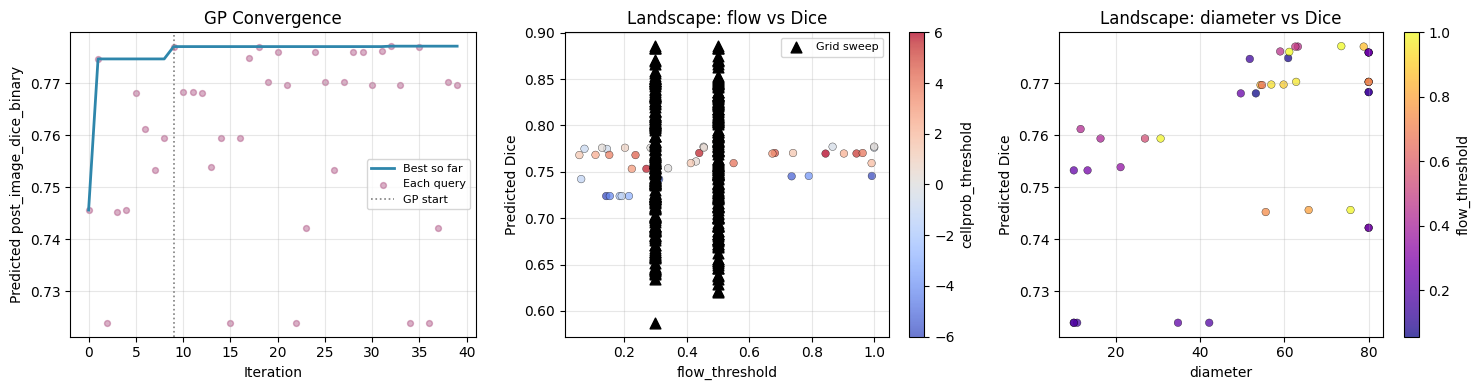

Saved: /Users/sorro/workspace/02604/project/project_cellpose-main/results_bbbc020/gp_optimization_plots.png


In [18]:
# ── Visualise GP convergence and parameter landscape ──────────────────────────

if not HAS_SKOPT or summary_df.empty:
    print("Run Sections 10 and 13 first.")
else:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # Plot 1: convergence curve
    axes[0].plot(gp_history_df["best_so_far"].values,
                 color="#2E86AB", linewidth=2, label="Best so far")
    axes[0].scatter(range(len(gp_history_df)),
                    gp_history_df["predicted_dice"].values,
                    alpha=0.4, s=18, color="#A23B72", label="Each query")
    axes[0].axvline(GP_N_INITIAL_POINTS - 1,
                    color="gray", linestyle=":", lw=1.2, label="GP start")
    axes[0].set_xlabel("Iteration")
    axes[0].set_ylabel(f"Predicted {RF_TARGET_METRIC}")
    axes[0].set_title("GP Convergence")
    axes[0].legend(fontsize=8)
    axes[0].grid(True, alpha=0.3)

    # Plot 2: flow_threshold vs Dice (colour = cellprob)
    sc2 = axes[1].scatter(
        gp_history_df["flow_threshold"],
        gp_history_df["predicted_dice"],
        c=gp_history_df["cellprob_threshold"],
        cmap="coolwarm", alpha=0.75, s=30, edgecolors="k", linewidths=0.3
    )
    if RF_TARGET_METRIC in summary_df.columns:
        axes[1].scatter(
            summary_df["flow_threshold"], summary_df[RF_TARGET_METRIC],
            marker="^", s=60, color="black", zorder=5, label="Grid sweep"
        )
        axes[1].legend(fontsize=8)
    plt.colorbar(sc2, ax=axes[1], label="cellprob_threshold")
    axes[1].set_xlabel("flow_threshold")
    axes[1].set_ylabel("Predicted Dice")
    axes[1].set_title("Landscape: flow vs Dice")
    axes[1].grid(True, alpha=0.3)

    # Plot 3: diameter vs Dice (colour = flow)
    sc3 = axes[2].scatter(
        gp_history_df["diameter"],
        gp_history_df["predicted_dice"],
        c=gp_history_df["flow_threshold"],
        cmap="plasma", alpha=0.75, s=30, edgecolors="k", linewidths=0.3
    )
    plt.colorbar(sc3, ax=axes[2], label="flow_threshold")
    axes[2].set_xlabel("diameter")
    axes[2].set_ylabel("Predicted Dice")
    axes[2].set_title("Landscape: diameter vs Dice")
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    fig_path = os.path.join(SAVE_ROOT, "gp_optimization_plots.png")
    plt.savefig(fig_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {fig_path}")